In [40]:
import pandas as pd
import numpy as np
import re

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Project Goals**: NOLA Climate
The Team, **Mia Wilcox** and **Elina Xu**, are focused on the exploratory data analysis (EDA) and statistical modeling of New Orleans temperature and sea-level data. The team aims to utilize data science techniques including data cleaning, merging, and correlation analysis to quantify the relationship between rising temperatures and local sea-level changes. The website in which the analysis is located can be found [here](https://miawilcox18-hub.github.io/miawilcox.github.io/)

## **Collaboration Plans**
The team is planning to meet at least once a week, in person or on zoom. Consitent meetings will help us finalize our project and collaborate on what objectives to have at the end of the project. In order to keep in active communication with each other, we will be messaging if we have questions about anything on the project. We have a shared Github where we are both collaboraters. To stay on top of our objectives we have also created a checklist of what we want to get done every week to keep up with the milestones.

# **Table 1**

This table was created using the Global Historical Climatology Network Daily (GHCN-Daily) dataset, which is publicly available through NOAA’s National Centers for Environmental Information (NCEI) and accessible via Google BigQuery. The dataset contains daily weather observations collected from thousands of monitoring stations around the world. For this project, the team focused specifically on weather stations located in Louisiana and extracted data from 1970 through 2024. Each observation originally represented a single daily measurement recorded at a specific station, including variables such as the date of observation, the weather element measured (for example maximum or minimum temperature), and the recorded value. After collecting the full dataset, the data was tidied and aggregated so that each row represents the average monthly temperature measurements across Louisiana, including average maximum temperature, average minimum temperature, and calculated average temperature for each month.

The team chose this dataset because it provides long-term, reliable climate observations that can be used to analyze trends in temperature over time. This allows the project to explore questions such as how average temperatures in Louisiana have changed over the past several decades, whether seasonal temperature patterns have shifted, and how maximum and minimum temperatures compare across different months or years. Additionally, the dataset comes from a reputable and authoritative source, NOAA, which is widely used in climate and environmental research.

However, the team recognizes that there may still be limitations and potential sources of bias within the dataset. For example, the number and location of weather stations may vary across time, meaning some areas may be more represented than others. Additionally, aggregating daily observations into monthly averages may remove some variability or extreme events that could also be relevant to climate analysis. Despite these limitations, the dataset provides a strong and credible foundation for analyzing long-term temperature patterns in Louisiana.

In [42]:
temp_df = pd.read_csv("/content/drive/MyDrive/Data Colab Notebooks/louisiana_temp.csv") #importing louisiana temp data

temp_df.head()

,id,date,element,value,mflag,qflag,sflag,time,source_url,etl_timestamp,...,latitude,longitude,elevation,state,name,gsn_flag,hcn_crn_flag,wmoid,source_url_1,etl_timestamp_1
0,USC00160103,2017-09-06,TMIN,189.0,NaN,NaN,7,2400.0,ftp://ftp.ncei.noaa.gov/pub/data/ghcn/daily/by...,2023-07-19 20:43:46.152011 UTC,...,31.2483,-92.4486,23.5,LA,ALEXANDRIA 5 SSE,NaN,NaN,NaN,ftp://ftp.ncdc.noaa.gov/pub/data/ghcn/daily/gh...,2026-03-04 01:37:43.795564 UTC
1,USC00168444,2017-09-14,TOBS,156.0,NaN,NaN,7,700.0,ftp://ftp.ncei.noaa.gov/pub/data/ghcn/daily/by...,2023-07-19 20:44:09.594364 UTC,...,32.3794,-93.8019,57.3,LA,SHREVEPORT SOUTHERN HILLS,NaN,NaN,NaN,ftp://ftp.ncdc.noaa.gov/pub/data/ghcn/daily/gh...,2026-03-04 01:37:43.795564 UTC
2,USC00169074,2017-01-02,TOBS,144.0,NaN,NaN,7,800.0,ftp://ftp.ncei.noaa.gov/pub/data/ghcn/daily/by...,2023-07-19 20:30:38.755679 UTC,...,31.2022,-93.5725,55.2,LA,TOLEDO BEND LAKE,NaN,NaN,NaN,ftp://ftp.ncdc.noaa.gov/pub/data/ghcn/daily/gh...,2026-03-04 01:37:43.795564 UTC
3,USC00169074,2017-09-17,TMIN,194.0,NaN,NaN,7,800.0,ftp://ftp.ncei.noaa.gov/pub/data/ghcn/daily/by...,2023-07-19 20:44:09.594364 UTC,...,31.2022,-93.5725,55.2,LA,TOLEDO BEND LAKE,NaN,NaN,NaN,ftp://ftp.ncdc.noaa.gov/pub/data/ghcn/daily/gh...,2026-03-04 01:37:43.795564 UTC
4,USC00166130,2017-01-08,SNWD,0.0,NaN,NaN,7,NaN,ftp://ftp.ncei.noaa.gov/pub/data/ghcn/daily/by...,2023-07-19 20:31:01.051409 UTC,...,29.9431,-89.9508,0.9,LA,CHALMETTE,NaN,NaN,NaN,ftp://ftp.ncdc.noaa.gov/pub/data/ghcn/daily/gh...,2026-03-04 01:37:43.795564 UTC


This table has a lot of information that is not needed. We only wish to study max temperature and min temperature, then using these 2 variables create and average temperature based off each month and year.

In [43]:
temp = temp_df[temp_df["element"].isin(["TMAX", "TMIN"])].copy() #keeping on temperature rows

In [44]:
temp["date"] = pd.to_datetime(temp["date"]) #converting the date column

In [45]:
temp["year"] = temp["date"].dt.year #creating year and month columns
temp["month"] = temp["date"].dt.month

NOAA stores temps in tenths of °C. So we need to convert the temperature back to regular °C by dividing the value by 10

In [46]:
temp["value"] = temp["value"] / 10

Right now, each row is either TMAX or TMIN, we want to convert them into columns so we use the pivot action to do that.

In [47]:
temp_pivot = temp.pivot_table(
    index=["year", "month"],
    columns="element",
    values="value",
    aggfunc="mean"
).reset_index()

In [48]:
temp_pivot["AVG_TEMP"] = (temp_pivot["TMAX"] + temp_pivot["TMIN"]) / 2 #creating and average temperature

In [49]:
temp_pivot.rename(columns={
    "TMAX": "max_temp_c",
    "TMIN": "min_temp_c"
}, inplace=True) #renaming columns

In [50]:
temp_pivot.head() #a look at the final dataframe after data has been tidied

element,year,month,max_temp_c,min_temp_c,AVG_TEMP
0,1970,1,13.925000,2.576471,8.250735
1,1970,2,16.405882,3.244444,9.825163
2,1970,3,20.638462,8.031250,14.334856
3,1970,4,26.456250,13.652381,20.054315
4,1970,5,29.418182,16.200000,22.809091


## **Summary Statistics**

In [51]:
temp_pivot["AVG_TEMP"].mean()

np.float64(19.204103904733458)

This statistic calculates the overall average temperature in Louisiana across the dataset. This is useful because it provides a baseline temperature level that can be compared against yearly temperatures to determine whether temperatures are increasing over time.

In [52]:
temp_pivot["max_temp_c"].max()

36.800000000000004

This identifies the highest recorded average maximum temperature in the dataset. Examining maximum temperatures helps determine whether extreme heat events are becoming more common or severe over time.

# **Table 2**

This second table contains data on sea level measurements along the Louisiana coast. The dataset was obtained from the National Oceanic and Atmospheric Administration (NOAA) Tides and Currents program, which provides long-term observations from coastal tide gauge stations across the United States. The data used in this table comes from a Louisiana tide gauge station and includes monthly mean sea level measurements. Each row represents a specific month and year, and the variables include the year, month, the measured monthly mean sea level (Monthly_MSL), a calculated linear trend value, and high and low confidence interval estimates for the trend.

The team chose this dataset because sea level rise is one of the most significant consequences of climate change affecting coastal regions such as Louisiana. Rising sea levels can increase the risk of flooding, coastal erosion, and land loss, making this data especially relevant for understanding environmental change in the state. By analyzing this dataset alongside temperature data, the team can explore whether increasing temperatures correspond with changes in sea level trends. The dataset also provides long-term observations beginning in the mid-20th century, allowing for analysis of patterns and changes over several decades. Furthermore, because the data originates from NOAA, a well-established federal scientific agency, the dataset is considered reliable and credible for studying long-term environmental trends.

The sea level values include both positive and negative measurements because they are recorded relative to a reference datum rather than an absolute height. Positive values indicate months when sea level was above the reference level, while negative values indicate months when sea level was below it. These fluctuations are normal due to seasonal and environmental factors, but long-term trends can still reveal whether sea levels are increasing over time.


In [53]:
sealevel_df = pd.read_csv("/content/drive/MyDrive/Data Colab Notebooks/louisiana_sea_level.csv") #importing lousiana sea level data
sealevel_df.head()

,Year,Month,Monthly_MSL,Linear_Trend,High_Conf.,Low_Conf.
0,1947,1,-0.528,-0.618,-0.602,-0.634
1,1947,2,-0.619,-0.617,-0.601,-0.633
2,1947,3,-0.579,-0.616,-0.600,-0.633
3,1947,4,-0.582,-0.616,-0.600,-0.632
4,1947,5,-0.559,-0.615,-0.599,-0.631


We are removing hidden space from column names so each column can be inferred through panda as a variable

In [54]:
sealevel_df.columns = sealevel_df.columns.str.strip()

In [55]:
sealevel_df.columns #checking column names

Index(['Year', 'Month', 'Monthly_MSL', 'Linear_Trend', 'High_Conf.',
       'Low_Conf.'],
      dtype='object')

In [56]:
sealevel_df.dtypes #checking dtypes

,0
Year,int64
Month,int64
Monthly_MSL,float64
Linear_Trend,float64
High_Conf.,float64
Low_Conf.,float64


Both Year and Month are int64 so Panda recognizes them as quantitative variables, we now want to filter out the data from only 1970 to 2024, so it can match the previous data's time stamps

In [57]:
sealevel_df = sealevel_df[(sealevel_df["Year"] >= 1970) & (sealevel_df["Year"] <= 2024)].copy()

To make the sea level data easier to interpret, the measurements were converted from meters to centimeters by multiplying the values by 100. Using centimeters allows for clearer interpretation of smaller variations in sea level over time.

In [58]:
tidy_sea = sealevel_df[["Year","Month","Monthly_MSL"]].rename(
    columns={
        "Year":"year",
        "Month":"month",
        "Monthly_MSL":"sea_level"
    }
).sort_values(["year","month"])
tidy_sea.head()

,year,month,sea_level
271,1970,1,-0.479
272,1970,2,-0.500
273,1970,3,-0.390
274,1970,4,-0.375
275,1970,5,-0.337


## **Summary Statistics**

In [59]:
tidy_sea["sea_level"].mean()

np.float64(-0.1408161648177496)

The mean sea level value represents the average deviation from the reference level across the dataset. Because the measurements are recorded relative to a baseline rather than as absolute ocean height, positive values indicate months where sea level was above the reference level, while negative values indicate months where it was below it.

In [60]:
tidy_sea["sea_level"].max()

0.21

The maximum sea level value represents the largest positive deviation from the reference sea level during the observed time period, indicating the month when water levels were highest relative to the baseline.

# **Table 3**

This third table contains precipitation data collected at the New Orleans Airport weather station in Louisiana. The dataset includes daily precipitation measurements obtained from NOAA daily summaries. Each row in the original dataset represents one day of recorded precipitation, along with the station identifier, station name, and date of observation.

The team selected this dataset because precipitation is another important environmental factor that may be related to sea level and climate patterns in Louisiana. Rainfall can influence coastal water levels, flooding risk, and broader environmental conditions, making it a useful variable to study alongside temperature and sea level. Because the data comes from a Louisiana weather station and covers a long period of time, it is geographically and historically consistent with the other datasets used in this project.

To prepare the table for analysis, the DATE column was converted into datetime format so that year and month could be extracted. The daily precipitation values were then grouped by year and month to calculate average monthly precipitation. This created a tidy dataset with year, month, and precipitation columns that matches the structure of the temperature and sea level tables, allowing for easier comparison and merging across datasets.

In [61]:
precip_df = pd.read_csv(("/content/drive/MyDrive/Data Colab Notebooks/louisiana_precipitation.csv"))

precip_df.head()

,STATION,NAME,DATE,PRCP
0,USW00012916,"NEW ORLEANS AIRPORT, LA US",1/1/70,0.00
1,USW00012916,"NEW ORLEANS AIRPORT, LA US",1/2/70,0.00
2,USW00012916,"NEW ORLEANS AIRPORT, LA US",1/3/70,0.00
3,USW00012916,"NEW ORLEANS AIRPORT, LA US",1/4/70,0.00
4,USW00012916,"NEW ORLEANS AIRPORT, LA US",1/5/70,0.95


Now, it's time to tidy up the data.

In [62]:
# convert DATE to datetime
precip_df["DATE"] = pd.to_datetime(precip_df["DATE"])

# extract year and month
precip_df["year"] = precip_df["DATE"].dt.year
precip_df["month"] = precip_df["DATE"].dt.month

# keep only needed columns
precip_tidy = precip_df[["year", "month", "PRCP"]].copy()

# keep the same time range as the other tables
precip_tidy = precip_tidy[(precip_tidy["year"] >= 1970) & (precip_tidy["year"] <= 2024)]

# group by year and month to get total monthly precipitation
precip_tidy = (
    precip_tidy.groupby(["year", "month"], as_index=False)["PRCP"]
    .sum()
    .rename(columns={"PRCP": "precipitation (inch)"})
)

precip_tidy.head()

/tmp/ipykernel_763/3982602560.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  precip_df["DATE"] = pd.to_datetime(precip_df["DATE"])


,year,month,precipitation (inch)
0,1976,1,2.61
1,1976,2,3.85
2,1976,3,3.08
3,1976,4,0.28
4,1976,5,5.58


## **Summary Statistics**

The precipitation table provides another climate-related variable that may help explain changes in sea level. Monthly precipitation totals are useful because they capture how much rainfall accumulated during each month, which can affect runoff, flooding, and coastal water conditions. Studying precipitation alongside temperature and sea level helps expand the analysis beyond only two environmental variables.

In [63]:
precip_tidy["precipitation (inch)"].mean()

np.float64(5.32641156462585)

This statistic represents the average monthly precipitation across the dataset. It provides a baseline for understanding how wet or dry a typical month is in Louisiana over the study period.

In [64]:
precip_tidy["precipitation (inch)"].max()

25.919999999999998

This statistic identifies the wettest month in the dataset. Looking at extreme precipitation values helps reveal whether unusually rainy periods may align with higher sea levels or other climate-related changes.

# **Merged Dataset**

To better understand how environmental variables interact, the three datasets (temperature, sea level, and precipitation) were merged using the shared variables year and month. This creates a single dataset where each row represents one month and contains all relevant variables.

Combining the datasets allows for direct comparison between temperature, sea level, and precipitation over the same time periods, which is essential for identifying relationships and trends.

In [65]:
merged_df = pd.merge(temp_pivot, tidy_sea, on=["year", "month"], how="inner")
merged_df = pd.merge(merged_df, precip_tidy, on=["year", "month"], how="inner")

merged_df = merged_df.sort_values(["year", "month"]).reset_index(drop=True)

merged_df.head()

,year,month,max_temp_c,min_temp_c,AVG_TEMP,sea_level,precipitation (inch)
0,1977,8,32.400000,22.369697,27.384848,-0.259,16.12
1,1977,9,31.922727,20.366667,26.144697,-0.249,13.48
2,1977,10,25.640000,12.554167,19.097083,-0.371,4.33
3,1977,11,20.558333,9.337500,14.947917,-0.287,8.77
4,1977,12,16.695455,2.833333,9.764394,-0.324,4.15


In [66]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  240 non-null    int32  
 1   month                 240 non-null    int32  
 2   max_temp_c            222 non-null    float64
 3   min_temp_c            222 non-null    float64
 4   AVG_TEMP              204 non-null    float64
 5   sea_level             240 non-null    float64
 6   precipitation (inch)  240 non-null    float64
dtypes: float64(5), int32(2)
memory usage: 11.4 KB


The merged dataset is now tidy form because each row represents one unique month and year, and each column represents a single variable: maximum temperature, minimum temperature, average temperature, sea level, and precipitation. This structure is appropriate for exploratory data analysis and future modeling.



# **Exploratory Data Analysis (EDA)**

The following graphs and tables explore patterns and relationships between temperature, sea level, and precipitation over time. The goal is to identify trends and determine whether these variables are related.

## 1. Overall Summary Statistics

Before visualizing the data, it is useful to examine summary statistics for the merged dataset. Measures such as the mean, standard deviation, minimum, and maximum provide an overview of the scale and variation of each variable.

In [67]:
merged_df[["max_temp_c", "min_temp_c", "AVG_TEMP", "sea_level", "precipitation (inch)"]].describe() #no need to describe the year and month

,max_temp_c,min_temp_c,AVG_TEMP,sea_level,precipitation (inch)
count,222.000000,222.000000,204.000000,240.000000,240.000000
mean,24.894824,13.599167,19.249651,-0.116450,5.482375
std,6.897987,7.652100,6.997710,0.130932,3.982809
min,7.500000,-4.150000,3.225000,-0.432000,0.060000
25%,18.900000,7.059722,13.486458,-0.211500,2.880000
50%,25.924194,13.393056,19.435491,-0.118500,4.435000
75%,31.045000,21.261364,26.251961,-0.022500,7.105000
max,36.800000,25.250000,30.425000,0.154000,19.810000


# 2. Temperature Trend Over Time

This table summarizes the average temperature over time. The light blue line represents the yearly average temperature, while the orange line represents a five-year rolling average, which smooths short-term fluctuations and highlights longer-term temperature trends.

From the graph, we can see that although temperatures vary from year to year, the smoothed trend line suggests relatively stable temperatures with slight fluctuations over time. This type of visualization is useful for identifying long-term climate patterns and provides a foundation for comparing temperature trends with other environmental indicators, such as sea level changes in Louisiana.

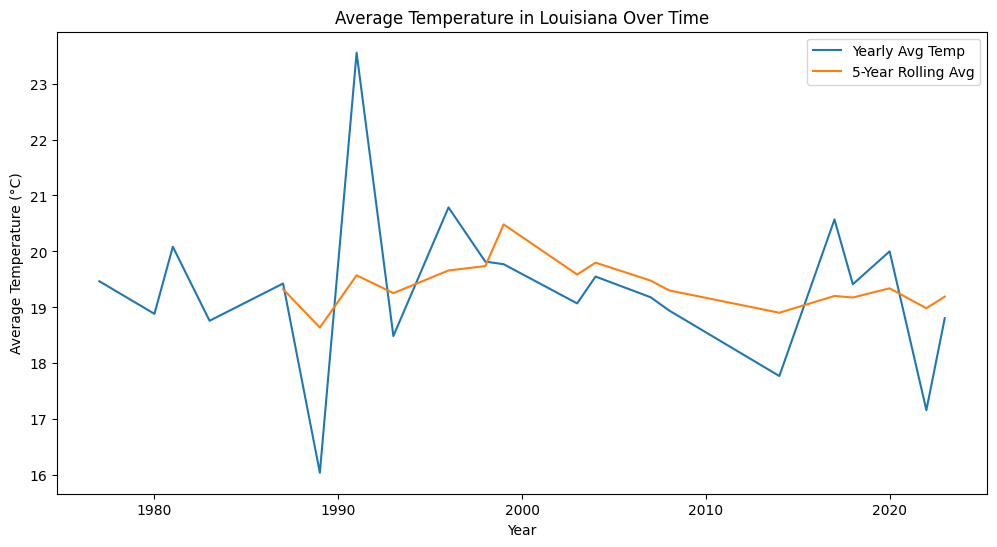

In [68]:
import matplotlib.pyplot as plt

temp_yearly = (
    merged_df.groupby("year", as_index=False)["AVG_TEMP"]
    .mean()
    .sort_values("year")
)

temp_yearly["temp_smooth"] = temp_yearly["AVG_TEMP"].rolling(window=5).mean()

plt.figure(figsize=(12,6))
plt.plot(temp_yearly["year"], temp_yearly["AVG_TEMP"], label="Yearly Avg Temp")
plt.plot(temp_yearly["year"], temp_yearly["temp_smooth"], label="5-Year Rolling Avg")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.title("Average Temperature in Louisiana Over Time")
plt.legend()
plt.show()

# 3. Sea Level Trend Overtime

This graph displays the yearly average sea level over time. The rolling average helps reveal the long-term direction of change by reducing month-to-month fluctuations. This is important because the project is specifically interested in whether sea level is changing over time and whether that change may be associated with other climate variables.

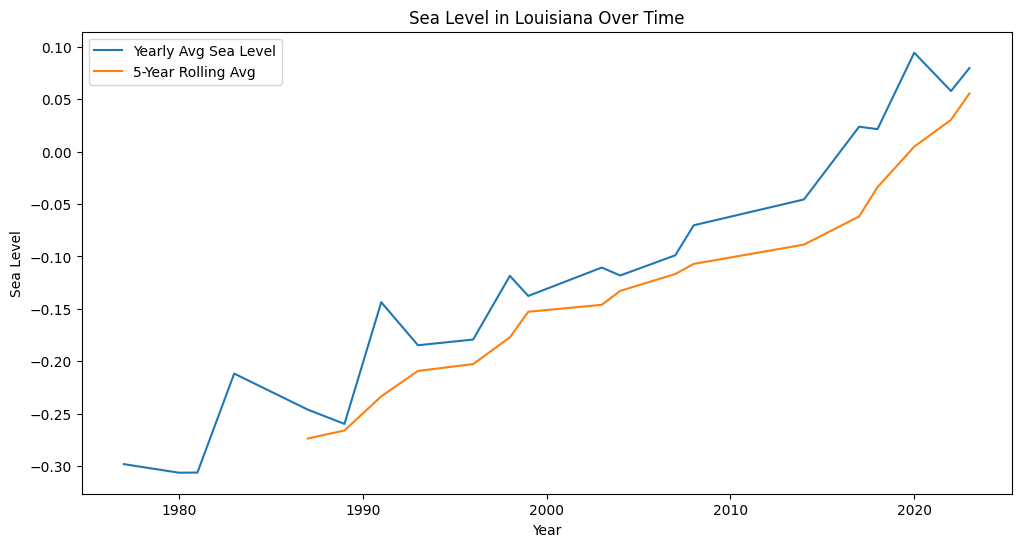

In [69]:
sea_yearly = (
    merged_df.groupby("year", as_index=False)["sea_level"]
    .mean()
    .sort_values("year")
)

sea_yearly["sea_smooth"] = sea_yearly["sea_level"].rolling(window=5).mean()

plt.figure(figsize=(12,6))
plt.plot(sea_yearly["year"], sea_yearly["sea_level"], label="Yearly Avg Sea Level")
plt.plot(sea_yearly["year"], sea_yearly["sea_smooth"], label="5-Year Rolling Avg")
plt.xlabel("Year")
plt.ylabel("Sea Level")
plt.title("Sea Level in Louisiana Over Time")
plt.legend()
plt.show()

# 4. Precipitation Over Time

This graph shows the trend in yearly precipitation in Louisiana over time. The values fluctuate from year to year, indicating that rainfall is more variable and less consistent over long periods.

This lack of a steady increase is expected because precipitation is influenced by short-term weather patterns, such as storms and seasonal conditions, rather than long-term warming alone. While climate change is strongly associated with rising temperatures and sea levels, its impact on precipitation is more complex and does not necessarily result in a consistent increase over time.

Overall, this graph suggests that precipitation does not follow the same long-term upward trend as temperature, highlighting that different environmental variables respond differently to climate change.

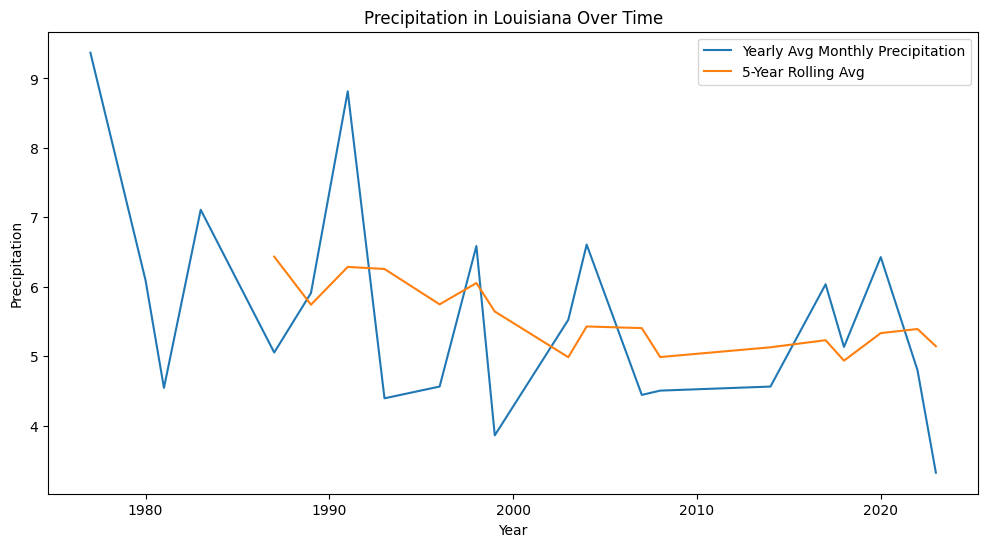

In [70]:
precip_yearly = (
    merged_df.groupby("year", as_index=False)["precipitation (inch)"]
    .mean()
    .sort_values("year")
)

precip_yearly["precip_smooth"] = precip_yearly["precipitation (inch)"].rolling(window=5).mean()

plt.figure(figsize=(12,6))
plt.plot(precip_yearly["year"], precip_yearly["precipitation (inch)"], label="Yearly Avg Monthly Precipitation")
plt.plot(precip_yearly["year"], precip_yearly["precip_smooth"], label="5-Year Rolling Avg")
plt.xlabel("Year")
plt.ylabel("Precipitation")
plt.title("Precipitation in Louisiana Over Time")
plt.legend()
plt.show()

Together, these graphs show that temperature and sea level exhibit upward trends over time, while precipitation remains highly variable. This suggests that not all environmental variables respond to long-term climate change in the same way.

# 5. Correlation Table

This correlation table shows the strength and direction of the relationships between average temperature, sea level, and precipitation. The correlation between temperature and sea level is very close to zero (-0.004), indicating no strong linear relationship between these two variables in this dataset. Similarly, the correlation between precipitation and sea level (0.019) is also very weak, suggesting that precipitation does not significantly influence sea level changes.

There is a slightly higher correlation between temperature and precipitation (0.187), but this value is still relatively low, indicating only a weak positive relationship. Overall, the results suggest that none of the variables have a strong linear relationship with one another, and that sea level changes may be influenced by additional factors not captured in this dataset.

In [71]:
merged_df[["max_temp_c", "min_temp_c", "AVG_TEMP", "sea_level", "precipitation (inch)"]].corr()

,max_temp_c,min_temp_c,AVG_TEMP,sea_level,precipitation (inch)
max_temp_c,1.000000,0.873470,0.964886,-0.037539,0.112102
min_temp_c,0.873470,1.000000,0.970686,0.075483,0.221700
AVG_TEMP,0.964886,0.970686,1.000000,-0.004475,0.187107
sea_level,-0.037539,0.075483,-0.004475,1.000000,0.019439
precipitation (inch),0.112102,0.221700,0.187107,0.019439,1.000000


# 6. Temperature Vs. Sea Level

This scatterplot compares average temperature and sea level, with a regression line used to summarize the overall relationship. The points are scattered across the graph with no clear pattern, and the regression line is nearly flat, indicating a very weak linear relationship between temperature and sea level.

While both temperature and sea level show upward trends over time individually, this graph suggests that temperature alone does not strongly predict sea level changes at the monthly level. This implies that sea level is influenced by additional long-term factors beyond short-term temperature variation.

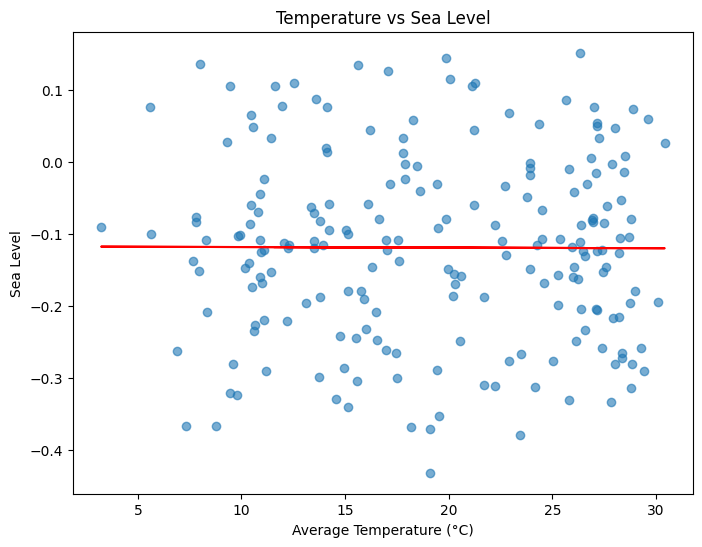

In [72]:
plt.figure(figsize=(8,6))
plt.scatter(merged_df["AVG_TEMP"], merged_df["sea_level"], alpha=0.6)

# regression line
import numpy as np
reg_df = merged_df[["AVG_TEMP", "sea_level"]].dropna()
x = reg_df["AVG_TEMP"]
y = reg_df["sea_level"]
m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b, color="red")

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Sea Level")
plt.title("Temperature vs Sea Level")
plt.show()

# 7. Precipitation Vs. Sea Level

This scatterplot shows the relationship between precipitation and sea level, with a regression line included to highlight the overall trend. The data points are widely dispersed, and the regression line is nearly flat, indicating a very little positive linear relationship between precipitation and sea level.

Although there are some higher precipitation values, sea level does not consistently increase or decrease in response. This suggests that precipitation is not a strong predictor of sea level changes and is likely influenced by short-term weather variability rather than long-term trends.

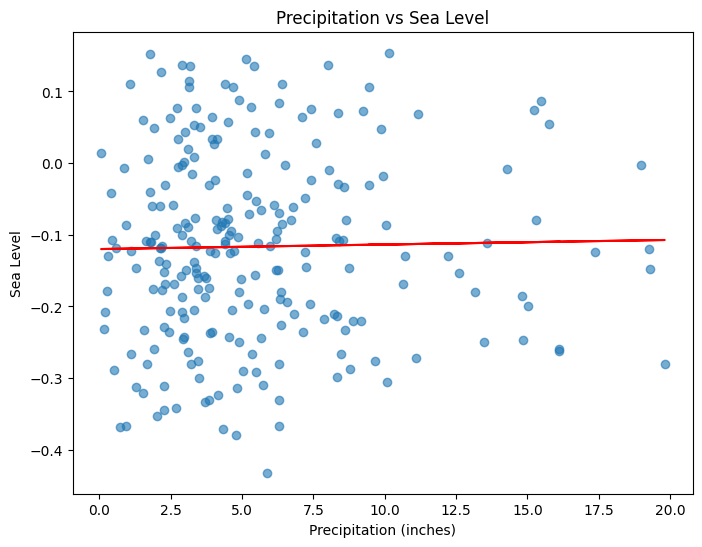

In [73]:
plt.figure(figsize=(8,6))
plt.scatter(merged_df["precipitation (inch)"], merged_df["sea_level"], alpha=0.6)

reg_df = merged_df[["precipitation (inch)", "sea_level"]].dropna()
x = reg_df["precipitation (inch)"]
y = reg_df["sea_level"]
m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b, color="red")

plt.xlabel("Precipitation (inches)")
plt.ylabel("Sea Level")
plt.title("Precipitation vs Sea Level")
plt.show()

# Cross Tabulation

This cross-tabulation shows how months are distributed across broad temperature categories. While the main variables are continuous, grouping temperature into categories allows for a table-based comparison of how seasonal timing relates to cooler or hotter conditions.

In [74]:
merged_df["temp_category"] = pd.cut(
    merged_df["AVG_TEMP"],
    bins=3,
    labels=["Cool", "Moderate", "Hot"]
)

pd.crosstab(merged_df["temp_category"], merged_df["month"])

month,1,2,3,4,5,6,7,8,9,10,11,12
temp_category,,,,,,,,,,,,
Cool,14,9,2,0,0,0,0,0,0,0,6,15
Moderate,3,8,15,13,1,0,0,0,0,17,11,4
Hot,0,0,0,2,14,17,16,18,17,2,0,0


# **Model Questions**

Based on the trends observed in the exploratory data analysis, the team plans to investigate models that better reflect the behavior of the data.

## Model Idea 1: Predicting Sea Level Over Time
The first model will examine how sea level changes over time by using year as a predictor.

- **Dependent variable:** sea_level  
- **Independent variable:** year  
- **Possible method:** linear regression  

This model is supported by the clear upward trend observed in the sea level time series graph. Unlike temperature and precipitation, sea level shows a consistent increase over time, making time a strong predictor.

## Model Idea 2: Explaining Sea Level Using Temperature and Precipitation

The second model will test whether temperature and precipitation help explain variation in sea level.

- **Dependent Variable:** sea_level
- **Independent Variables:** temperature and precipitation.
- **Possible Method:** Multiple Linear Regression

However, based on the exploratory analysis, both temperature and precipitation show high variability and weak correlation with sea level. This suggests that these variables may not be strong predictors on their own, but the model can still be used to test whether they provide any additional explanatory power.

### Additional Statistical Question
The team may also test whether there is a statistically significant correlation between temperature and sea level.

- **Variables of interest:** AVG_TEMP and sea_level
- **Possible method:** correlation analysis / hypothesis test

This question is appropriate because the project is interested in whether warming temperatures are associated with changes in sea level over time.

Based on the weak correlations observed, these models may have limited predictive power, but they are useful for testing whether any statistically significant relationships exist.

In [76]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Data Colab Notebooks/Elina_Mia_Final.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Data Colab Notebooks/Elina_Mia_Final.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 739865 bytes to /content/drive/MyDrive/Data Colab Notebooks/Elina_Mia_Final.html
